In [1]:
# Giovanni: use utils.read_gbq to pull the data, it caches the data
# it takes almost the same input as pandas.read_gbq 
# see the docstrings in utils.py if in doubt
from utils import read_gbq
import matplotlib.pyplot as plt
from tableone import TableOne
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [2]:
# test different values here 
WINDOW_SIZE=12
OFFSET=6

In [3]:
PROCEDURES=Path("./procedures")
# PROJECT_ID=os.getenv('PROJECTID')
PROJECT_ID="clinical-entity-extraction"

In [4]:
transfusion_df=read_gbq(PROCEDURES / "transfusion.sql",project_id=PROJECT_ID)
transfusion_df=transfusion_df.sort_values(by=['patientunitstayid','offset'])
transfusion_df.offset=transfusion_df.offset/60

Downloading: 100%|██████████|


In [6]:
transfusion_df=read_gbq(PROCEDURES / "transfusion.sql",project_id=PROJECT_ID)
transfusion_df=transfusion_df.sort_values(by=['patientunitstayid','offset'])
transfusion_df.offset=transfusion_df.offset/60

# HGB Data
hgb_df=read_gbq(PROCEDURES / "hgb.sql",project_id=PROJECT_ID)
hgb_df=hgb_df.sort_values(by=['patientunitstayid','offset'])
hgb_df.offset=hgb_df.offset/60

# Fluids Data
fluids_df=read_gbq(PROCEDURES / "fluid_balance.sql",project_id=PROJECT_ID)
fluids_df=fluids_df.sort_values(by=['patientunitstayid','offset'])
fluids_df.offset=fluids_df.offset/60

# Demographic data 
demographics_df=read_gbq(PROCEDURES / "demographics.sql",project_id=PROJECT_ID)

# GI Bleeder
gb_df=read_gbq(PROCEDURES / "gb.sql",project_id=PROJECT_ID)
gb_df['gi_bleeder']=True

# Length of stay
lengthStay_df = (read_gbq(PROCEDURES / "lengthStay.sql", project_id=PROJECT_ID)
                 .sort_values(by=['patientunitstayid']))
time_columns = ['ICU_Stay', 'Time_prior_ICU', 'hospitalDischargeOffset']
lengthStay_df[time_columns] = lengthStay_df[time_columns] / 60
lengthStay_df['Total_time'] = lengthStay_df['hospitalDischargeOffset'] - lengthStay_df['Time_prior_ICU']


Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|


In [7]:
from tqdm import tqdm
from utils import treatment_effect
# Giovanni : utils.treatment_effect computes the average (or any function you want) HGB in window size before transfusion (treatment) as baseline
# and after transfusion intitiation + a OFFSET for estimating the post treatment effect

data=[]
for ix,group in tqdm(transfusion_df.groupby('patientunitstayid')):
    data.append(treatment_effect(
        group,
        hgb_df[hgb_df.patientunitstayid.isin(group.patientunitstayid)],
        WINDOW_SIZE,
        OFFSET,
        'mean')
        )

100%|██████████| 20450/20450 [02:34<00:00, 132.07it/s]


In [8]:
def merge_info(original, to_merge, merge_by):
    filter_merge =  to_merge[to_merge[merge_by].isin(original[merge_by].unique())]
    merged = pd.merge(original, filter_merge, how='left')
    return merged

In [9]:
#Giovanni: nomenclature note
# baseline-> HGB before transfusion
# treatment_offset-> time in hours of the transfusion
# treatment_value-> volume in ml of the transfusion
# post_treatment-> HGB after the trnasfusion
# treatment_effect-> difference in HGB before and after tratment (transfusion)



df=pd.concat(data).groupby('patientunitstayid').first().reset_index() # for now we only keep the first transfusion
df['treatment_effect_quartile']=pd.qcut(df.treatment_effect,[.0,.25,.5,.75,1.],precision=1).astype(str)
df['baseline_quartile']=pd.qcut(df.baseline,[.0,.25,.5,.75,1.],precision=1).astype(str)

df=df.merge(demographics_df,on='patientunitstayid',validate='1:1')
# df.age=df.age.replace('> 89',91).astype(float)
df.age=df.age.replace('> 89', 91)
df.age=pd.to_numeric(df.age, errors='coerce')
df['age_quartile']=pd.qcut(df.age,[.0,.25,.5,.75,1.],precision=1).astype(str)

df=df.merge(gb_df,on='patientunitstayid',how='left',validate='1:1')
df.gi_bleeder=df.gi_bleeder.fillna(False)

# Add length of stay to df
df=merge_info(df, lengthStay_df, 'patientunitstayid')

temp=fluids_df.merge(df[['patientunitstayid','treatment_offset']],on='patientunitstayid')
temp['delta']=temp.offset-temp.treatment_offset
temp=temp[(temp.delta<0)&(temp.delta>-6)]
temp=temp.groupby('patientunitstayid').apply(lambda data: data.sort_values(by='delta').iloc[-1,:],include_groups=True)
temp=temp.reset_index(drop=True).drop(['treatment_offset','delta','celllabel','offset'],axis=1)
df=df.merge(temp,on='patientunitstayid',how='left',validate='1:1')

exclude=['_window_size','_offset','aggfunc']
categorical=['gender','age_quartile','ethnicity','gi_bleeder','icu_outcome','hosp_outcome']
continuous=['initial_weight','treatment_effect','treatment_value','treatment_offset','baseline','nettotal', 'Total_time']



df=df[df.treatment_effect.notna()] # removes patients with missing values on treatment effect
df=df[df.treatment_offset>=0] # remove patients who receives transfusion before ICU admission

C:\Users\hash\AppData\Local\Temp\ipykernel_36900\216327882.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.gi_bleeder=df.gi_bleeder.fillna(False)
C:\Users\hash\AppData\Local\Temp\ipykernel_36900\216327882.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp=temp.groupby('patientunitstayid').apply(lambda data: data.sort_values(by='delta').iloc[-1,:],include_groups=True)


In [10]:
len(data)

20450

In [11]:
from tableone import TableOne
t1=TableOne(df,
         columns=categorical+continuous,
         categorical=categorical,
         groupby='treatment_effect_quartile',
         pval=True,
         )

# use print(t1.to_latex()) to make it in latex, looks much better
t1

Grouped by treatment_effect_quartile                                                                                   
                                                                          Missing        Overall    (-9.6, 0.4]     (0.4, 1.2]     (1.2, 2.2]    (2.2, 12.1] P-Value
n                                                                                          12556           3037           3237           3194           3088        
gender, n (%)               Female                                                   5858 (46.7)    1201 (39.5)    1343 (41.5)    1501 (47.0)    1813 (58.7)  <0.001
                            Male                                                     6698 (53.3)    1836 (60.5)    1894 (58.5)    1693 (53.0)    1275 (41.3)        
age_quartile, n (%)         (4.9, 55.0]                                              3232 (25.7)     830 (27.3)     816 (25.2)     802 (25.1)     784 (25.4)   0.002
                            (55.0, 67.0]                                             3259 (26.0)     766 (25.2)     878 (27.1)     835 (26.1)     780 (25.3)        
                            (67.0, 77.0]                                             3087 (24.6)     778 (25.6)     816 (25.2)     776 (24.3)     717 (23.2)        
                            (77.0, 91.0]                                             2978 (23.7)     663 (21.8)     727 (22.5)     781 (24.5)     807 (26.1)        
ethnicity, n (%)                                                                        42 (0.3)       10 (0.3)       14 (0.4)       11 (0.3)        7 (0.2)   0.018
                            African American                                         1516 (12.1)     345 (11.4)     384 (11.9)     389 (12.2)     398 (12.9)        
                            Asian                                                      216 (1.7)       47 (1.5)       40 (1.2)       53 (1.7)       76 (2.5)        
                            Caucasian                                                9543 (76.0)    2325 (76.6)    2468 (76.2)    2453 (76.8)    2297 (74.4)        
                            Hispanic                                                   569 (4.5)      142 (4.7)      152 (4.7)      120 (3.8)      155 (5.0)        
                            Native American                                            116 (0.9)       26 (0.9)       30 (0.9)       25 (0.8)       35 (1.1)        
                            Other/Unknown                                              554 (4.4)      142 (4.7)      149 (4.6)      143 (4.5)      120 (3.9)        
gi_bleeder, n (%)           False                                                   12223 (97.3)    2942 (96.9)    3140 (97.0)    3119 (97.7)    3022 (97.9)   0.037
                            True                                                       333 (2.7)       95 (3.1)       97 (3.0)       75 (2.3)       66 (2.1)        
icu_outcome, n (%)          deceased                                                  1022 (8.1)      289 (9.5)      260 (8.0)      229 (7.2)      244 (7.9)   0.007
                            discharged                                              11534 (91.9)    2748 (90.5)    2977 (92.0)    2965 (92.8)    2844 (92.1)        
hosp_outcome, n (%)         deceased                                                 1687 (13.4)     423 (13.9)     435 (13.4)     389 (12.2)     440 (14.2)   0.081
                            discharged                                              10869 (86.6)    2614 (86.1)    2802 (86.6)    2805 (87.8)    2648 (85.8)        
initial_weight, mean (SD)                                                     541    82.1 (25.6)    85.4 (25.5)    87.0 (28.1)    82.4 (24.5)    73.6 (21.8)  <0.001
treatment_effect, mean (SD)                                                     0      1.3 (1.5)     -0.6 (1.0)      0.8 (0.2)      1.7 (0.3)      3.2 (1.0)  <0.001
treatment_value, mean (SD)                                                      0  35

In [12]:
t1_pd=t1.tableone
t1_latex=t1_pd.to_latex()

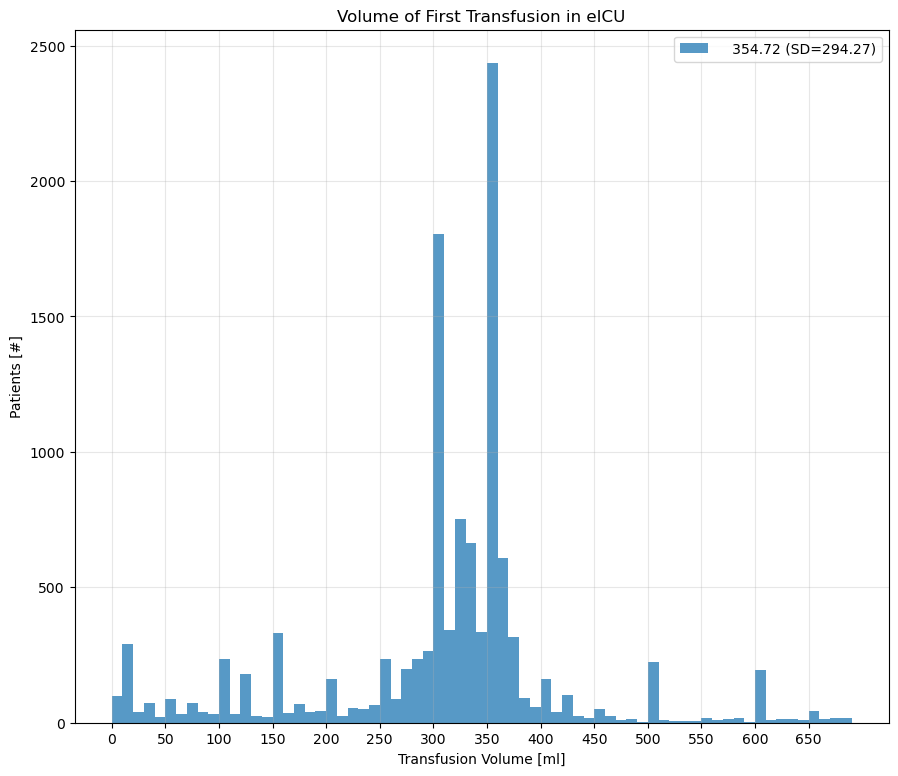

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Giovanni: this is invariant to WINDOW_SIZE and OFFSET

def labeled_plot(data:pd.Series,ax,label:str,f,**kwargs):
    mn=data.mean()
    sd=data.std()
    ulabel=f'{label}   {mn:.2f} (SD={sd:.2f})'
    return getattr(data.plot,f)(ax=ax,label=ulabel,**kwargs)

fig,ax=plt.subplots(figsize=(10.5,9))
_=labeled_plot(df.treatment_value,ax,'','hist',bins=np.arange(0,700,10),alpha=.75)
_=ax.set_xticks(np.arange(0,700,50))
_=ax.set_xlabel('Transfusion Volume [ml]')
_=ax.set_ylabel('Patients [#]')
_=ax.set_title('Volume of First Transfusion in eICU')
_=ax.grid(alpha=.3)
_=ax.legend()

<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hash\AppData\Local\Temp\ipykernel_36900\102904041.py:16: SyntaxWarning: invalid escape sequence '\D'
  _=ax[1].set_xlabel('$\Delta$ HGB [g/dL]')


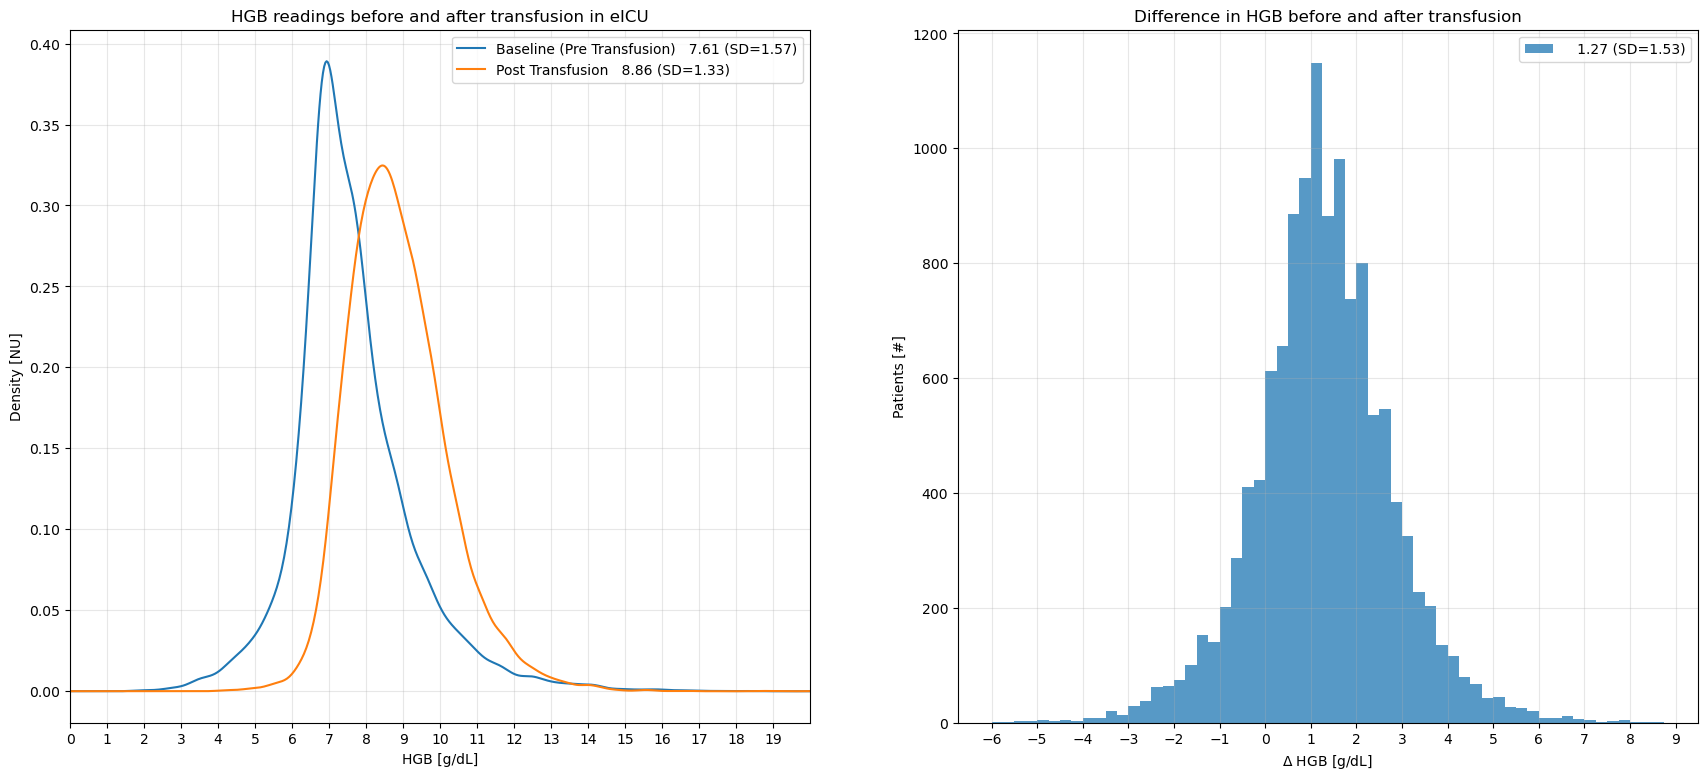

In [15]:
fig,ax=plt.subplots(1,2,figsize=(21,9))

_=labeled_plot(df.baseline,ax=ax[0],label='Baseline (Pre Transfusion)',f='kde')
_=labeled_plot(df.post_treatment,ax=ax[0],label='Post Transfusion',f='kde')

_=ax[0].legend()
_=ax[0].set_xlim([0,20])
_=ax[0].set_xticks(np.arange(0,20,1.))
_=ax[0].set_xlabel('HGB [g/dL]')
_=ax[0].set_ylabel('Density [NU]')
_=ax[0].set_title('HGB readings before and after transfusion in eICU')
_=ax[0].grid(alpha=.3)

_=labeled_plot(df.treatment_effect,ax=ax[1],label='',f='hist',bins=np.arange(-6,9,.25),alpha=.75)
_=ax[1].set_xticks(np.arange(-6,10,1.))
_=ax[1].set_xlabel('$\Delta$ HGB [g/dL]')
_=ax[1].set_ylabel('Patients [#]')
_=ax[1].set_title('Difference in HGB before and after transfusion')
_=ax[1].grid(alpha=.3)
_=ax[1].legend()

In [206]:
# Note for Hashem: I bet you can improve this by a lot (but keep interpretability)
from sklearn.linear_model import Ridge
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
# from crlearn.evaluation import crossvalidate_regression
from sklearn.metrics import r2_score,root_mean_squared_error
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor

to_censor=['post_treatment','treatment_effect','icu_outcome','hosp_outcome']
outcome=['treatment_effect']
features=['baseline','age','gender','ethnicity','initial_weight','treatment_value','treatment_offset','nettotal','gi_bleeder']
categorical=['gender','ethnicity','gi_bleeder']
continuous=[val for val in features if val not in categorical]

X,y=df[features],df[outcome]
# y = y.values.ravel()

cnt_processor=Pipeline([('impute',SimpleImputer()),('scaling',StandardScaler())])
cat_processor=Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('ohe',OneHotEncoder(drop='if_binary',sparse_output=False,min_frequency=20))]) 
processor=ColumnTransformer([
    ('categorical',cat_processor,categorical),
    ('continuous',cnt_processor,continuous),
])

model_ridge=Pipeline([('processor',processor), ('regressor',Ridge(random_state=42))])
model_pca=Pipeline([('processor',processor), ('pca', PCA(n_components=0.8)), ('ridge',Ridge(random_state=42))])
model_forest = Pipeline([('processor',processor), ('regressor',RandomForestRegressor(random_state=0))])

cv=RepeatedKFold(n_splits=10,n_repeats=10)

In [203]:
def tracing_func(model):
    # Get the last model step coefficients (assumes it's linear and has coef_)
    coef = np.squeeze(model[-1].coef_)
    
    # Access the 'categorical' features from the ColumnTransformer
    fcat = model[0].named_transformers_['categorical'].get_feature_names_out(categorical)
    
    # Return a Series with coefficients and feature names
    return pd.Series(coef, index=[*fcat, *continuous])


# Tracing func for finding coefs when using PCA
def tracing_func_pca(model):
    pca = model.named_steps['pca']
    components = pca.components_ 

    processor = model.named_steps['processor']
    fcat = processor.named_transformers_['categorical'].get_feature_names_out(categorical)
    feature_names = [*fcat, *continuous]

    pca_df = pd.DataFrame(components, columns=feature_names)

    return pca_df.mean(axis=0)

# Tracing func for random forest
def tracing_func_rf(model):
    # Get the feature importances from the Random Forest model
    importances = model[-1].feature_importances_
    
    # Access the 'categorical' features from the ColumnTransformer
    fcat = model[0].named_transformers_['categorical'].get_feature_names_out(categorical)
    
    # Combine categorical and continuous features for the index
    all_features = [*fcat, *continuous]
    
    # Return a Series with feature importances and feature names
    return pd.Series(importances, index=all_features)


In [204]:
def train_ridge(model, apply_pca:bool):
    trace=[]
    scores=[]
    scoring=[r2_score,root_mean_squared_error]

    # if with_pca:
    #     trace.append(tracing_func_pca(model))
    # else:
    #     trace.append(tracing_func(model))  
    for train,test in cv.split(X,y):
        model=model.fit(X.iloc[train],y.iloc[train])
    
        y_pred=model.predict(X.iloc[test])
        scores.append([root_mean_squared_error(y.iloc[test],y_pred),r2_score(y.iloc[test],y_pred)])
        
        if apply_pca:
            trace.append(tracing_func_pca(model))
        else:
            trace.append(tracing_func(model)) 
    
        # trace.append(tracing_func_pca(model)) # Change tracing function if using PCA
        # trace.append(tracing_func(model))  

    scores_df = pd.DataFrame(scores, columns=['rmse', 'r2'])
    
    traces_df = pd.concat(trace, axis=1).T
    
    traces_df = traces_df[traces_df.mean().sort_values().index]
    
    return traces_df, scores_df


def train_forest(model): 
    trace=[]
    scores=[]
    scoring=[r2_score,root_mean_squared_error]

    for train, test in cv.split(X, y):
        y = y.values.ravel()
        model = model.fit(X.iloc[train], y[train])
        
        y_pred = model.predict(X.iloc[test])
        
        scores.append([root_mean_squared_error(y[test], y_pred), r2_score(y[test], y_pred)])
        
        trace.append(tracing_func_rf(model))
        
    scores_df = pd.DataFrame(scores, columns=['rmse', 'r2'])
    
    traces_df = pd.concat(trace, axis=1).T
    
    traces_df = traces_df[traces_df.mean().sort_values().index]
    
    return traces_df, scores_df

In [210]:
trace=[]
scores=[]
scoring=[r2_score,root_mean_squared_error]

# if with_pca:
#     trace.append(tracing_func_pca(model))
# else:
#     trace.append(tracing_func(model)) 
model=model_pca
for train,test in cv.split(X,y):
    model=model.fit(X.iloc[train],y.iloc[train])

    y_pred=model.predict(X.iloc[test])
    scores.append([root_mean_squared_error(y.iloc[test],y_pred),r2_score(y.iloc[test],y_pred)])
    
    # if apply_pca:
    trace.append(tracing_func_pca(model))
    # else:
    #     trace.append(tracing_func(model)) 

    # trace.append(tracing_func_pca(model)) # Change tracing function if using PCA
    # trace.append(tracing_func(model))  

scores_df = pd.DataFrame(scores, columns=['rmse', 'r2'])

traces_df = pd.concat(trace, axis=1).T

traces_df = traces_df[traces_df.mean().sort_values().index]


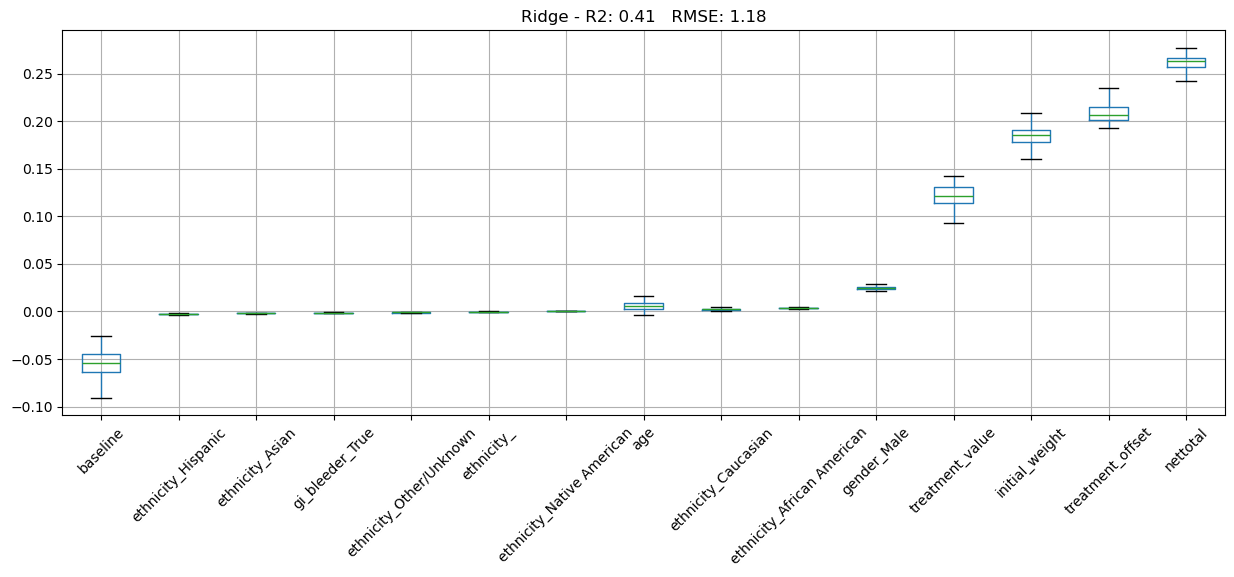

In [214]:
scores=pd.DataFrame(scores,columns=['rmse','r2'])
traces=pd.concat(trace,axis=1).T
traces=traces[traces.mean().sort_values().index]

# traces, scores=train_ridge(model, False)

fig,ax=plt.subplots(figsize=(15,5))
_=traces.boxplot(showfliers=False,rot=45,ax=ax)
_=ax.set_title(f'Ridge - R2: {scores.r2.mean():.2f}   RMSE: {scores.rmse.mean():.2f}')
plt.savefig('PCA_Ridge_7H_window.png', dpi=300)

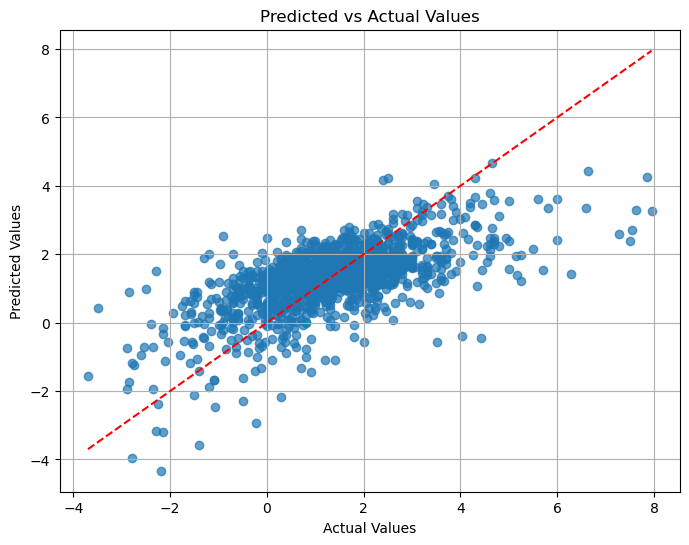

In [216]:
plt.figure(figsize=(8, 6))
plt.scatter(y.iloc[test], y_pred, alpha=0.7, label='Actual')
# plt.scatter(y.iloc[test], alpha=0.7, label='Predicted', color='red')
plt.plot([min(y.iloc[test]['treatment_effect']), max(y.iloc[test]['treatment_effect'])], [min(y.iloc[test]['treatment_effect']), max(y.iloc[test]['treatment_effect'])], color='red', linestyle='--')  # Line of perfect prediction
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.grid(True)
plt.savefig('PCA_Ridge_plot.png', dpi=300)
plt.show()

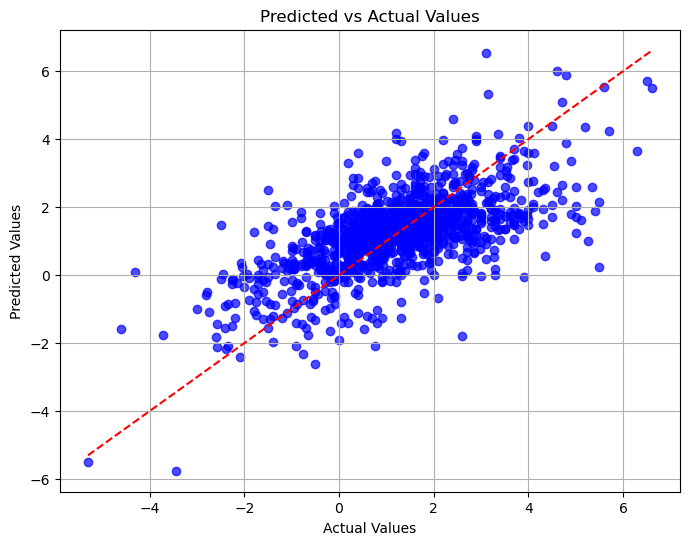

In [134]:
plt.figure(figsize=(8, 6))
plt.scatter(y[test], y_pred, alpha=0.7, label='Actual', color='blue')
# plt.scatter(y.iloc[test], alpha=0.7, label='Predicted', color='red')
plt.plot([min(y[test]), max(y[test])], [min(y[test]), max(y[test])], color='red', linestyle='--')  # Line of perfect prediction
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.grid(True)
plt.show()
